<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_2%2C_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción al Análisis Exploratorio de Datos (EDA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/01_introduccion_eda.ipynb)

In [99]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

In [100]:
# Importación de librerías específicas para este notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

# Introducción al Análisis Exploratorio de Datos (EDA)

## RA1 - Trabajo práctico N° 2, grupo N° 8

Tipos de datos o variables

*   `id`: Identificador único.
*   `precio`, `superficie_m2`, `precio_m2`, `antiguedad_años`: variables numericas continuas.
*   `habitaciones`: variable numerica discreta.
*   `barrio`: variable categórica.


In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Carga y Exploración Inicial

Primero, cargamos los datos y damos un "vistazo" rápido a su estructura. Usamos `pandas`, la librería por excelencia para el manejo de datos tabulares en Python.

In [102]:
# Esta función engloba código reutilizable para la gestión y carga de los datos
from utils.data import load_dataset

dataset_path = "/content/drive/MyDrive/datasets/propiedades/propiedades.csv"
datasetPropiedades = pd.read_csv(dataset_path)
dataset_path = "/content/drive/MyDrive/datasets/churn/clientes_churn.csv"
datasetChurn = pd.read_csv(dataset_path)
dataset_path = "/content/drive/MyDrive/datasets/desconocido/dataset_desconocido.csv"
datasetDesconocido = pd.read_csv(dataset_path)

# Pandas hace la magia, una carga directa se ve así:

In [103]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetPropiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


¿Qué representa cada fila del dataset? ¿Y cada columna?

¿Qué tipos de variables están presentes (numéricas continuas, discretas, categóricas)? ¿Todas las
variables tienen el tipo de dato correcto en el dataframe?



In [104]:
# Resumen de los tipos de datos y recuento de valores no nulos
datasetPropiedades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               800 non-null    int64  
 1   precio           768 non-null    float64
 2   superficie_m2    800 non-null    float64
 3   habitaciones     800 non-null    int64  
 4   antiguedad_años  752 non-null    float64
 5   barrio           800 non-null    object 
 6   precio_m2        768 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 43.9+ KB


¿Cuántas instancias contiene el dataset? ¿La cantidad es suficiente para sacar conclusiones?



---








## Calidad de los datos:






¿Existen valores faltantes? ¿En qué variables y con qué frecuencia?


Tenemos datos faltantes: precio y precio_m2 32, antiguedad_años 48.

En las variables `precio` y `precio_m2` 32, `antiguedad_años` 48.



¿Qué decisiones tomarían frente a cada caso de valor faltante? ¿Eliminar la fila, imputar, ignorar?


Si los valores faltantes son muchos para un tipo de dato no conviene eliminar, si el dato es numerico se puede reemplazar (imputar) por un valor estimado estadisticamente usando el promedio con los datos que no faltan, mientras no hayan datos atípicos (outliers), en ese caso es mejor utilizar la mediana. Si el dato es de tipo categórico es mejor usar la moda

En el caso que no falten muchos valores, sean del 1%-5% se pueden eliminar estos datos, no representan a una gran cantidad del dataset.
Si falta un dato y se desea **ignorar** depende de la lógica, si el dato es `piscina` y falta el dato que indique si posee o no, o si posee varias, indica que no posee, y que no se decidió anotar.


¿Existen valores que parezcan erróneos o inconsistentes (por ejemplo, superficies negativas,
precios iguales a cero)?



Vamos a verificar si existen valores negativos en las columnas numéricas que no deberían tenerlos, como `precio`, `superficie_m2`, `precio_m2`, `habitaciones` y `antiguedad_años`.

In [105]:
numeric_cols = ['precio', 'superficie_m2', 'precio_m2', 'antiguedad_años', 'habitaciones']

for col in numeric_cols:
    if col in datasetPropiedades.columns:
        negative_values = datasetPropiedades[datasetPropiedades[col] < 0]
        if not negative_values.empty:
            print(f"Se encontraron valores negativos en la columna '{col}':")
            display(negative_values)
        else:
            print(f"No se encontraron valores negativos en la columna '{col}'.")
    else:
        print(f"La columna '{col}' no existe en el dataset.")

No se encontraron valores negativos en la columna 'precio'.
No se encontraron valores negativos en la columna 'superficie_m2'.
No se encontraron valores negativos en la columna 'precio_m2'.
No se encontraron valores negativos en la columna 'antiguedad_años'.
No se encontraron valores negativos en la columna 'habitaciones'.


Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

In [106]:
import numpy as np
# Contabilizar valores nulos por columna
datasetPropiedades.isna().sum()

,0
id,0
precio,32
superficie_m2,0
habitaciones,0
antiguedad_años,48
barrio,0
precio_m2,32




---





---


## Relaciones entre variables:

¿Se identifica alguna variable en el dataset que sea el resultado de una operación matemática
entre otras columnas? De ser así, ¿esta variable aportaría información nueva al análisis? ¿Qué
impacto tendría incluirla en un análisis de correlación junto con sus variables de origen? Formular
una hipótesis al respecto y luego comprobar su validez mediante el cálculo o gráfico de correlación
correspondiente.

In [107]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
datasetPropiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


Se puede observar que si se realiza el producto entre `superficie_m2` y `precio_m2` se obtine el `precio`. No aporta información nueva `precio_m2` al estar contenida en las otras 2 variables.

Si 2 variables poseen dependencia funcional directa o colinealidad, es decir el coeficientes de correlación es muy alto. El impacto que puede causar en modelos de IA predictivos, es que se confunda al estár recibir la misma información 2 veces y desestabiliza los calculos internos, esto afecta las métricas de éxito.
Entonces si se realiza la matríz de correlación las 3 variables tendrán alto coeficiente de correlación.


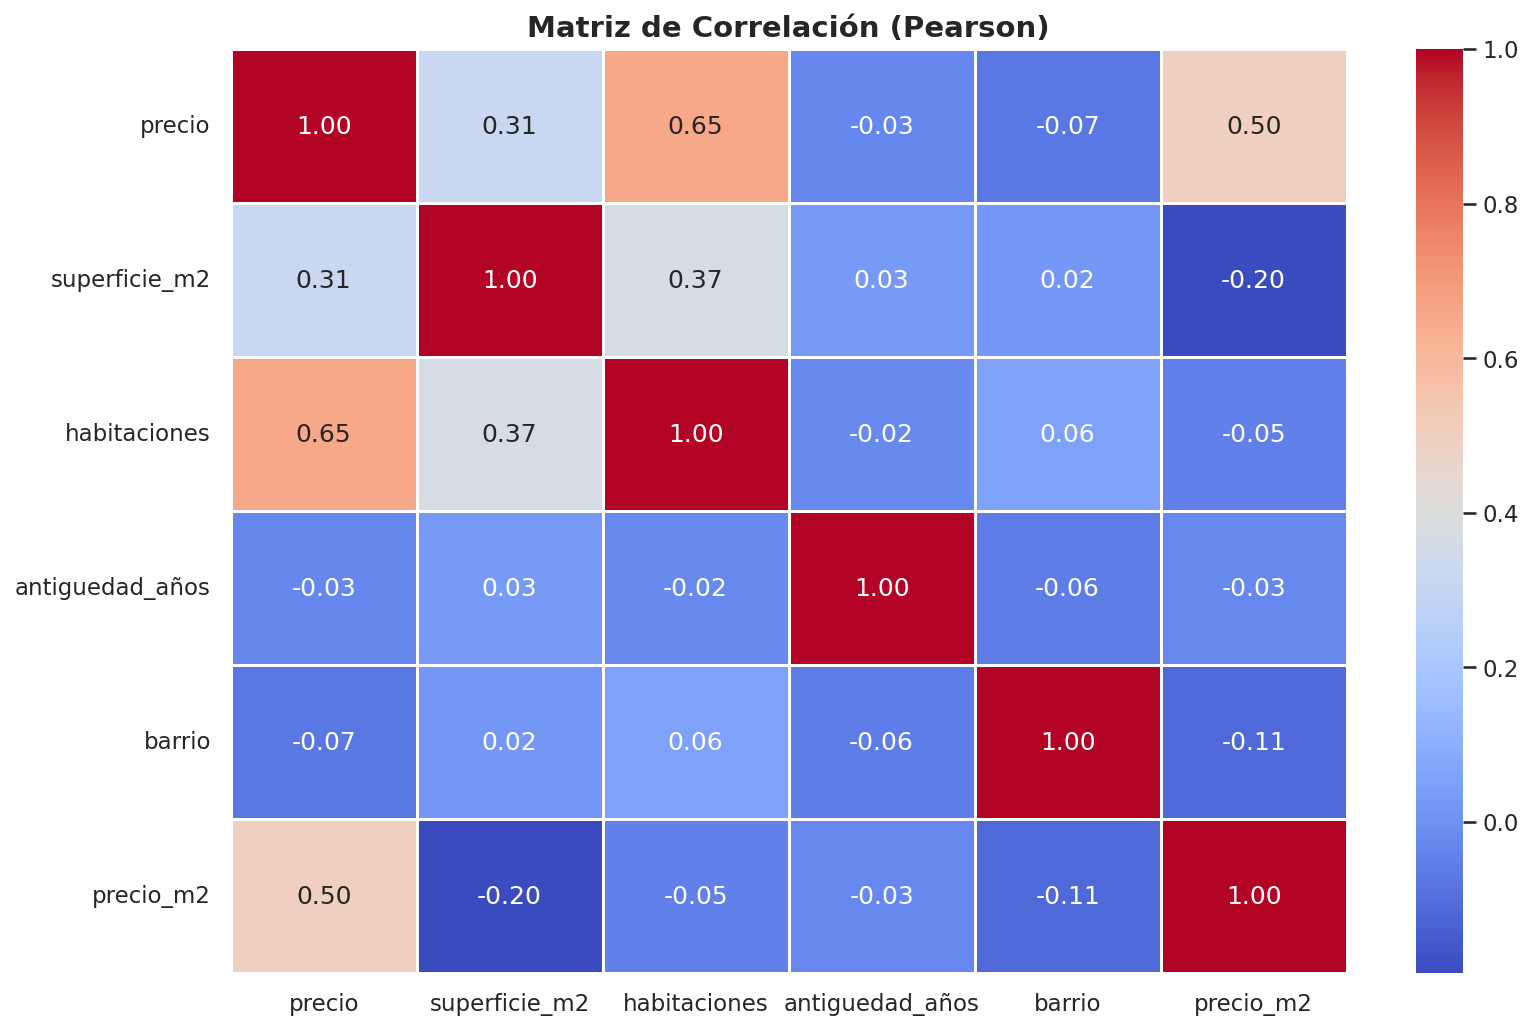

In [108]:
from sklearn.preprocessing import LabelEncoder

dataset_encoded = datasetPropiedades.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas, se pasa a numeros temporales debido a que aplicar la correlación estandar
# se trabaja con valores numéricos
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

Se puede observar que ese es el caso, si el modelo se encargase de predecir el valor de cada metro cuadrado del immueble en base a las demas variables del dataset lo mejor seria eliminar la columna del `precio_m2`.

¿Qué riesgo existiría al entrenar un algoritmo o modelo utilizando una variable de entrada que
tenga dependencia funcional directa con el valor que se quiere predecir (target)? ¿Cómo afectaría
a las métricas de éxito del modelo?  

El riesgo de entrenar un modelo con variables de entrada con dependencia directa a la variable salida (target) haria que empieze a memorizar, tomaria unicamente 2 variables de entrada en cuenta sin considerar las demás, debido a que poseen un vinculo matématico, esto se conoce como Target Leakage, porque se filtra la respuesta en dicho vinculo. Entonces el efecto de las metricas de éxito cuando comparamos con los resultados de entrenamiento puede llegar a ser perfecto, pero una vez que se le pruebe con nuevos datos el rendimiento se desploma.


¿Se observan diferencias de precio significativas entre barrios? Proponer una visualización que
permita comparar las distribuciones de precio por barrio de manera simultánea.

Lo lógico en la realidad es que los barrios mas seguros, y/o posean mas puntos de interes, sean los mas caros en cuanto al precio del immueble, entonces se puede comparar el precio promedio de cada barrio con un gráfico de barras como se muestra acontinuación.

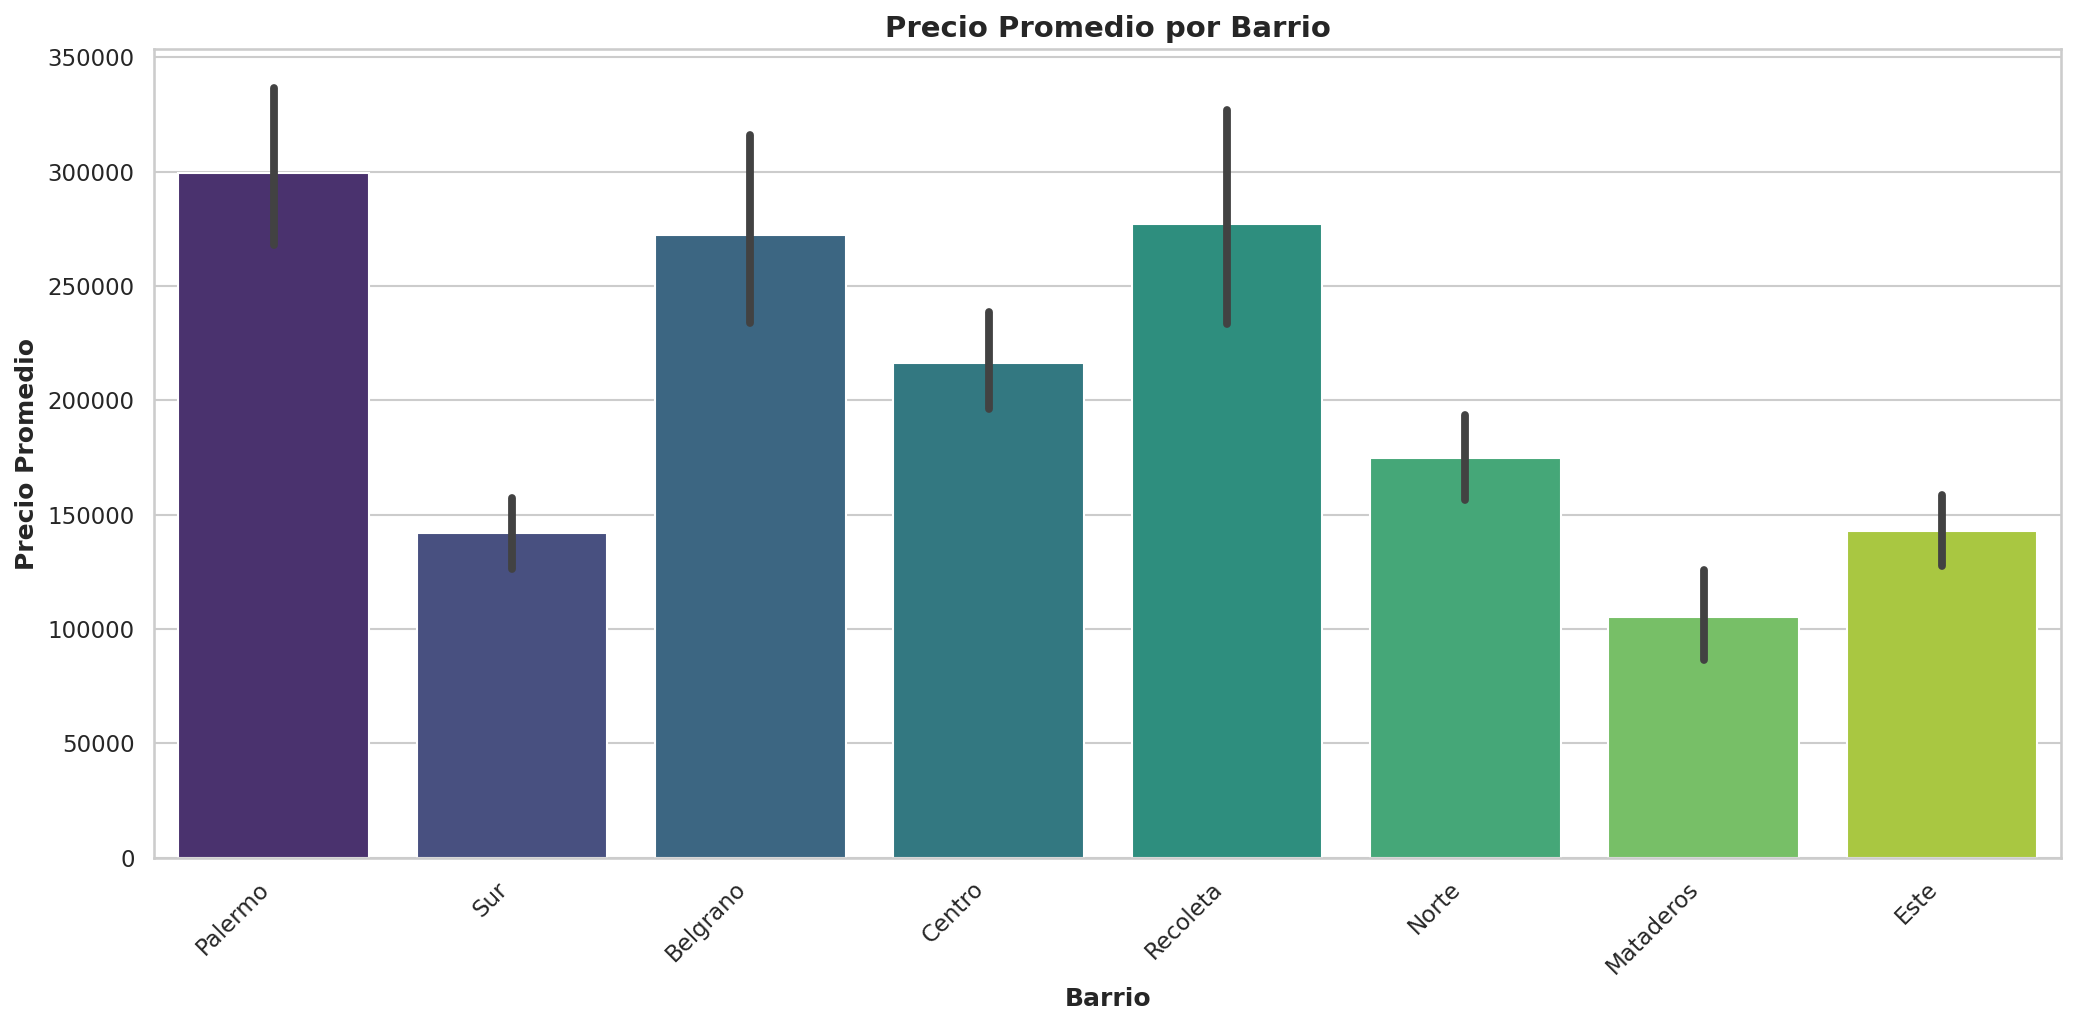

In [109]:
plt.figure(figsize=(14, 7))
sns.barplot(x='barrio', y='precio', data=datasetPropiedades, palette='viridis')
plt.title('Precio Promedio por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Podemos observar que Palermo es el barrio con los precios promedios mas altos, lo cual tiene sentido según lo anteriormente explicado, y mataderos posee los precios mas bajos en promedio.



---




---

## Visualizaciones:

Construir un heatmap de correlación para cada dataset. ¿Qué observan? ¿Hay variables
fuertemente correlacionadas entre sí?

## Resultados y Discusión

A partir de este EDA básico, hemos concluido que:
1. Nuestro *dataset* sufre de un **fuerte desbalance de clases**, requiriendo atención especial en la fase de modelado.
2. Identificamos y tratamos datos faltantes de manera fundamentada (imputación por mediana para numéricos, descarte para categóricos).
3. Confirmamos mediante correlaciones que factores biológicos como la edad, la glucosa y condiciones cardíacas preexistentes están ligados a la probabilidad de un ACV en nuestros datos.
4. Identificamos que variables como el `id` no aportan información y solo introducen ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** [Feature Engineering y Limpieza de Datos](02_feature_engineering_y_limpieza.ipynb).
- 🔄 **Relacionado:** Con el dataset limpio, estamos listos para entender qué hacen los modelos con esto [Introducción a la Clasificación](../03_machine_learning/01_introduccion_clasificacion.ipynb).

## Referencias
1. Dataset ACV: Healthcare Dataset Stroke Data (Kaggle).
2. [Documentación Oficial de Pandas](https://pandas.pydata.org/docs/)
3. [Documentación de Seaborn para Visualización Estadística](https://seaborn.pydata.org/)

---
## Entorno de Ejecución

In [110]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
